# Q1: What type of delays are occurring most at the airports related to air traffic? 

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches

In [4]:
FILE = Path("datasets/AA_ATFM_Delay.xlsx")
SHEET = "Blad1"
YEARS = [2023, 2024]   # use [2023] for only one year
df_AT = pd.read_excel("datasets/AirportTraffic.xlsx")

In [5]:
#setting the letter into what it is
delay_mapping = {
    "A": "Accident/Incident",
    "C": "ATC Capacity",
    "D": "De-icing",
    "E": "Equipment (non-ATC)",
    "G": "Aerodrome Capacity",
    "I": "Industrial Action (ATC)",
    "M": "Airspace Management",
    "N": "Industrial Action (non-ATC)",
    "O": "Other",
    "P": "Special Event",
    "R": "ATC Routeing",
    "S": "ATC Staffing",
    "T": "Equipment (ATC)",
    "V": "Environmental Issues",
    "W": "Weather",
    "NA": "Not specified"
}

EXOGENOUS_CAUSES = [
    "Accident/Incident",
    "De-icing",
    "Special Event",
    "Environmental Issues",
    "Weather"
]

ENDOGENOUS_CAUSES = [
    "Industrial Action (non-ATC)",
    "ATC Capacity",
    "Equipment (non-ATC)",
    "Aerodrome Capacity",
    "Industrial Action (ATC)",
    "Airspace Management",
    "ATC Routeing",
    "ATC Staffing",
    "Equipment (ATC)"
]

OTHER_CAUSES = ["Other", "Not specified"]

In [6]:
df_top20 = (
    df_AT.groupby("APT_ICAO")[["FLT_TOT_1", "FLT_DEP_1", "FLT_ARR_1"]] #Group by airport code
    .sum().sort_values(by="FLT_TOT_1",ascending=False) #Sum the values for each code of the 3 columns indicated
    .head(20).reset_index()) #Change "20" to change the number of airports analysed
# Adding airport's city name and state from original dataset
df_top20 = (df_top20.merge(df_AT[["APT_ICAO", "APT_NAME", "STATE_NAME"]]
                           .drop_duplicates(), on="APT_ICAO", how="left"))
airports_code_list = df_top20["APT_ICAO"].tolist()

In [7]:
df = pd.read_excel(FILE, sheet_name=SHEET)
df = df[df["YEAR"].isin(YEARS) & df["APT_ICAO"].isin(airports_code_list)].copy()

In [8]:
#what columns
delay_cols = sorted([
    c for c in df.columns
    if c.startswith("DLY_APT_ARR_") and c.endswith("_1") and c != "DLY_APT_ARR_1"
])

#find most-occurring type per (airport, year, month)
occ = (df[delay_cols].fillna(0) > 0)
group_keys = ["APT_ICAO", "YEAR", "MONTH_NUM"]
counts = occ.groupby([df[k] for k in group_keys]).sum()

best_col = counts.idxmax(axis=1)
best_code = (best_col.str.replace("DLY_APT_ARR_", "", regex=False)
                      .str.replace("_1", "", regex=False))

#table making
long_df = (
    best_code.reset_index(name="delay_code")
    .assign(
        Year=lambda d: d["YEAR"].astype(str),
        Month=lambda d: d["MONTH_NUM"].astype(str).str.zfill(2),
        delay_type=lambda d: d["delay_code"].map(delay_mapping)
    )
    .loc[:, ["Year", "Month", "APT_ICAO", "delay_type"]]
    .sort_values(["APT_ICAO", "Year", "Month"])
    .set_index("APT_ICAO")
)

#printing, but maybe remove it before committing?
display(long_df)
print("Rows:", len(long_df))

long_df.to_csv("datasets_rq4/df_delay_type.csv")

,Year,Month,delay_type
APT_ICAO,,,
EDDF,2023,01,Equipment (non-ATC)
EDDF,2023,02,Weather
EDDF,2023,03,Weather
EDDF,2023,04,Weather
EDDF,2023,05,Aerodrome Capacity
...,...,...,...
LTFM,2024,08,Weather
LTFM,2024,09,Weather
LTFM,2024,10,Weather


Rows: 480


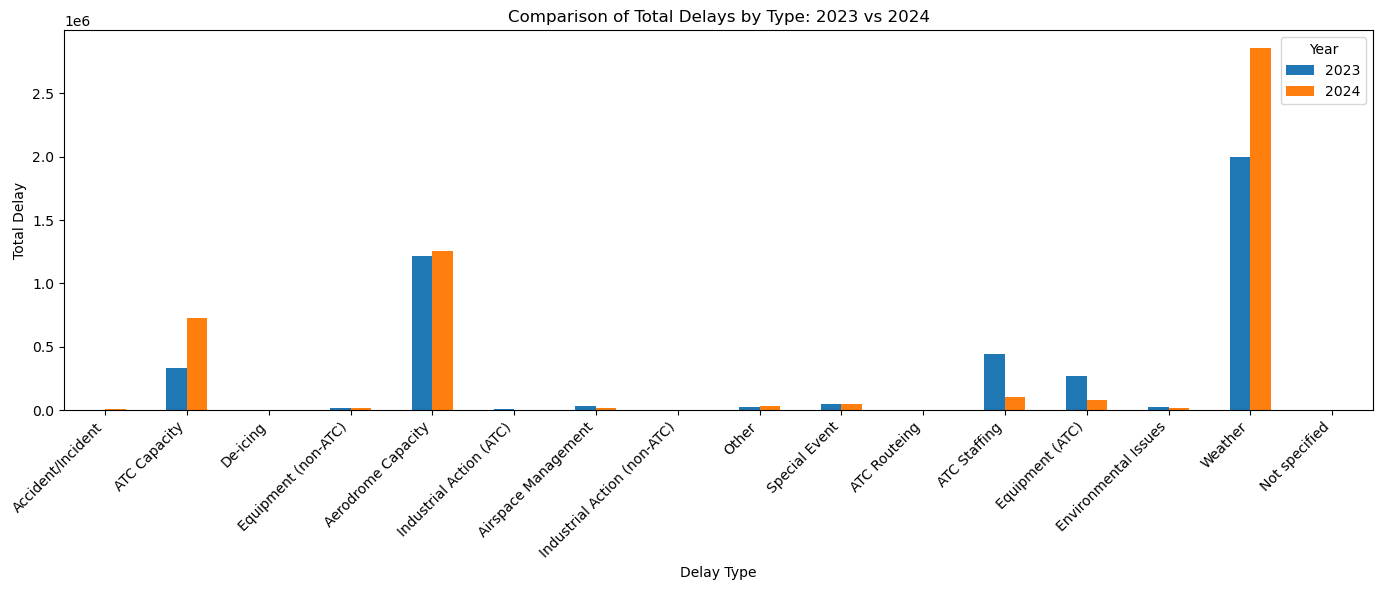

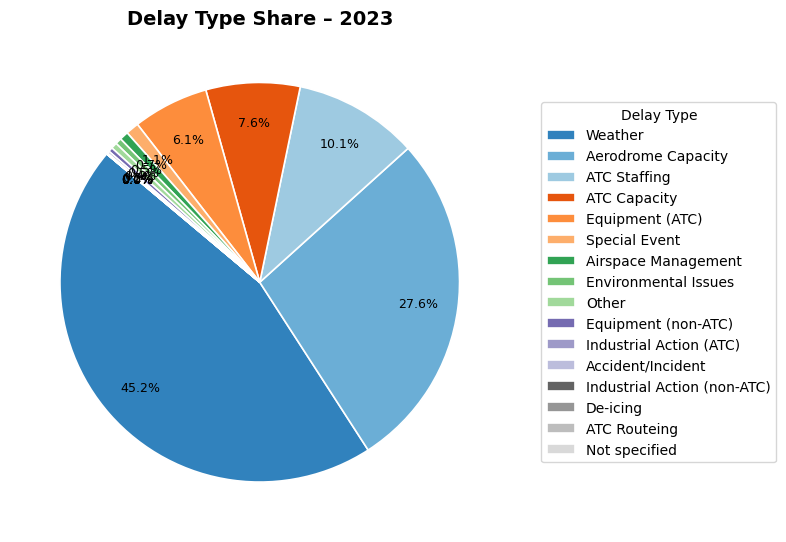

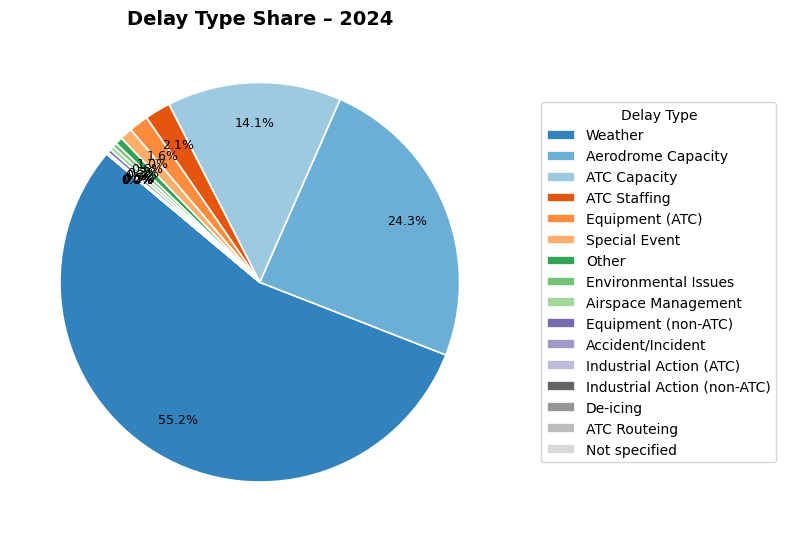

In [9]:

year_index = sorted(df["YEAR"].unique().tolist())
by_year_type = {}

for code, label in delay_mapping.items():    
    pat = fr"_{re.escape(code)}_"
    cols = [c for c in delay_cols if re.search(pat, c)]  
 
    if not cols:
        s = df.groupby("YEAR")[delay_cols].sum().sum(axis=1) * 0
    else:
        s = df.groupby("YEAR")[cols].sum().sum(axis=1)    
    by_year_type[label] = s.reindex(year_index).fillna(0)

delay_type_by_year_df = pd.DataFrame(by_year_type, index=year_index).fillna(0)

#bar chart: compare 2023 vs 2024 by delay type
years_to_plot = [y for y in YEARS if y in delay_type_by_year_df.index]
if years_to_plot:
    ax = delay_type_by_year_df.loc[years_to_plot].T.plot(
        kind="bar", figsize=(14, 6)
    )
    plt.title("Comparison of Total Delays by Type: " + " vs ".join(map(str, years_to_plot)))
    plt.ylabel("Total Delay")
    plt.xlabel("Delay Type")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Year")
    plt.tight_layout()
    plt.show()


#pie charts: one per year
for y in YEARS:
    if y in delay_type_by_year_df.index:
        series = delay_type_by_year_df.loc[y]
        if series.sum() > 0:
            # Sort slices so small ones don’t clump together
            series = series.sort_values(ascending=False)

            fig, ax = plt.subplots(figsize=(8, 8))            
            colors = plt.cm.tab20c(np.linspace(0, 1, len(series)))
            
            wedges, texts, autotexts = ax.pie(
                series,
                autopct="%1.1f%%",
                startangle=140,          
                colors=colors,
                pctdistance=0.8,         
                labeldistance=1.15,      
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
            )

            # Make % text readable
            for t in autotexts:
                t.set_color("black")
                t.set_fontsize(9)           
            plt.title(f"Delay Type Share – {y}", fontsize=14, fontweight='bold')           
            plt.legend(
                loc="center left",
                bbox_to_anchor=(1.05, 0.5),
                labels=series.index,
                title="Delay Type"
            )

            plt.tight_layout()
            plt.show()






The data shows that weather-related delays are the most significant contributor to total delays at airports for both 2023 and 2024, followed by aerodrome capacity and air traffic control (ATC)–related causes such as ATC capacity and ATC staffing.

In 2023, weather accounted for about 45% of all delays, while in 2024 it increased to over 55%, indicating a growing influence of weather disruptions. Although aerodrome capacity and ATC capacity delays also remain substantial, their relative shares have declined slightly as weather disruptions became more dominant.

Overall, the majority of these delay types fall under the broader category of Air Traffic Flow Management (ATFM) delays, and certain other delays are not taken into account in this metric, so a full picture of delays is shown in 1.1. But even then these delays can show a correlation between 2023 and 2024, or even between airports which is shown here underneath.

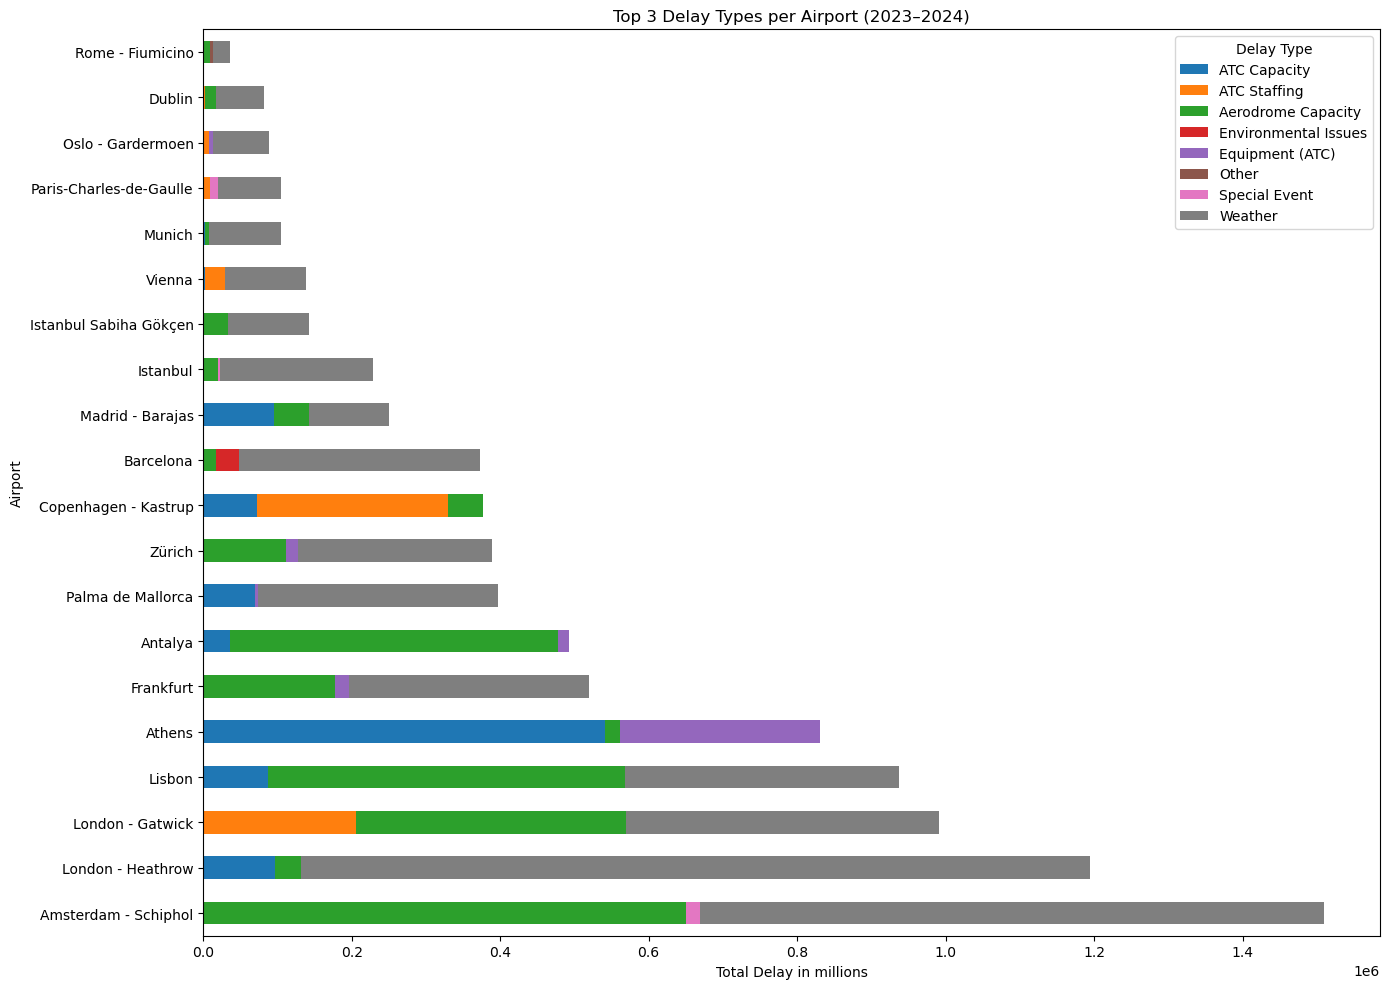

In [10]:

grp = df.groupby(["APT_ICAO", "APT_NAME"], dropna=False)

def sums_for_code_per_airport(code: str) -> pd.Series:    
    pat = fr"_{re.escape(code)}_"
    cols = [c for c in delay_cols if re.search(pat, c)]
    if not cols:        
        return grp[delay_cols[:0]].sum().sum(axis=1) * 0
    return grp[cols].sum().sum(axis=1)

per_airport = {}
for code, label in delay_mapping.items():
    per_airport[label] = sums_for_code_per_airport(code)

agg_airport = pd.DataFrame(per_airport).fillna(0).reset_index()

#compute each airport's top-3 delay types
rows = []
for _, r in agg_airport.iterrows():
    airport = r["APT_NAME"]
    icao = r["APT_ICAO"]
    totals = r.drop(labels=["APT_ICAO", "APT_NAME"])
    top3 = totals.sort_values(ascending=False).head(3)    
    if top3.sum() == 0:
        continue
    for rank, (label, val) in enumerate(top3.items(), start=1):
        rows.append({"APT_ICAO": icao, "APT_NAME": airport,
                     "Delay Type": label, "Total Delay": float(val), "Rank": rank})

top3_df = pd.DataFrame(rows)

#chart: horizontal stacked bar
pivot = (top3_df.pivot_table(index="APT_NAME", columns="Delay Type",
                             values="Total Delay", aggfunc="sum").fillna(0))
row_totals = pivot.sum(axis=1)
order = row_totals.sort_values(ascending=False).index
pivot_sorted = pivot.loc[order]

ax = pivot_sorted.plot(kind="barh", stacked=True, figsize=(14, 10))
ax.set_title("Top 3 Delay Types per Airport (2023–2024)")
ax.set_xlabel("Total Delay in millions")
ax.set_ylabel("Airport")
plt.tight_layout()
plt.show()






This figure shows the distribution of total delays by type across major European airports. The chart reveals that Amsterdam–Schiphol, London–Heathrow, London–Gatwick, Lisbon, and Athens experience the highest total delays overall.

The dominant source of delay across most airports is weather, represented in grey, followed closely by aerodrome capacity (green) and ATC-related causes such as ATC capacity and ATC staffing. These patterns are consistent with broader air traffic flow management (ATFM) issues, where delays are largely due to constraints in airspace and airport capacity rather than airline or passenger factors.

Other pionts of intrest are that certain major airports, like Instanbul and Rome have low to very low delays. This either indicates that ATFM delays are not big at these airports or that data of certain days/months are missing, as in 1.1 these airports have more delays. In the case of istanbul they have a lot of data missing, and Rome has a lot of days with zero delays more so than the other data suggest. 

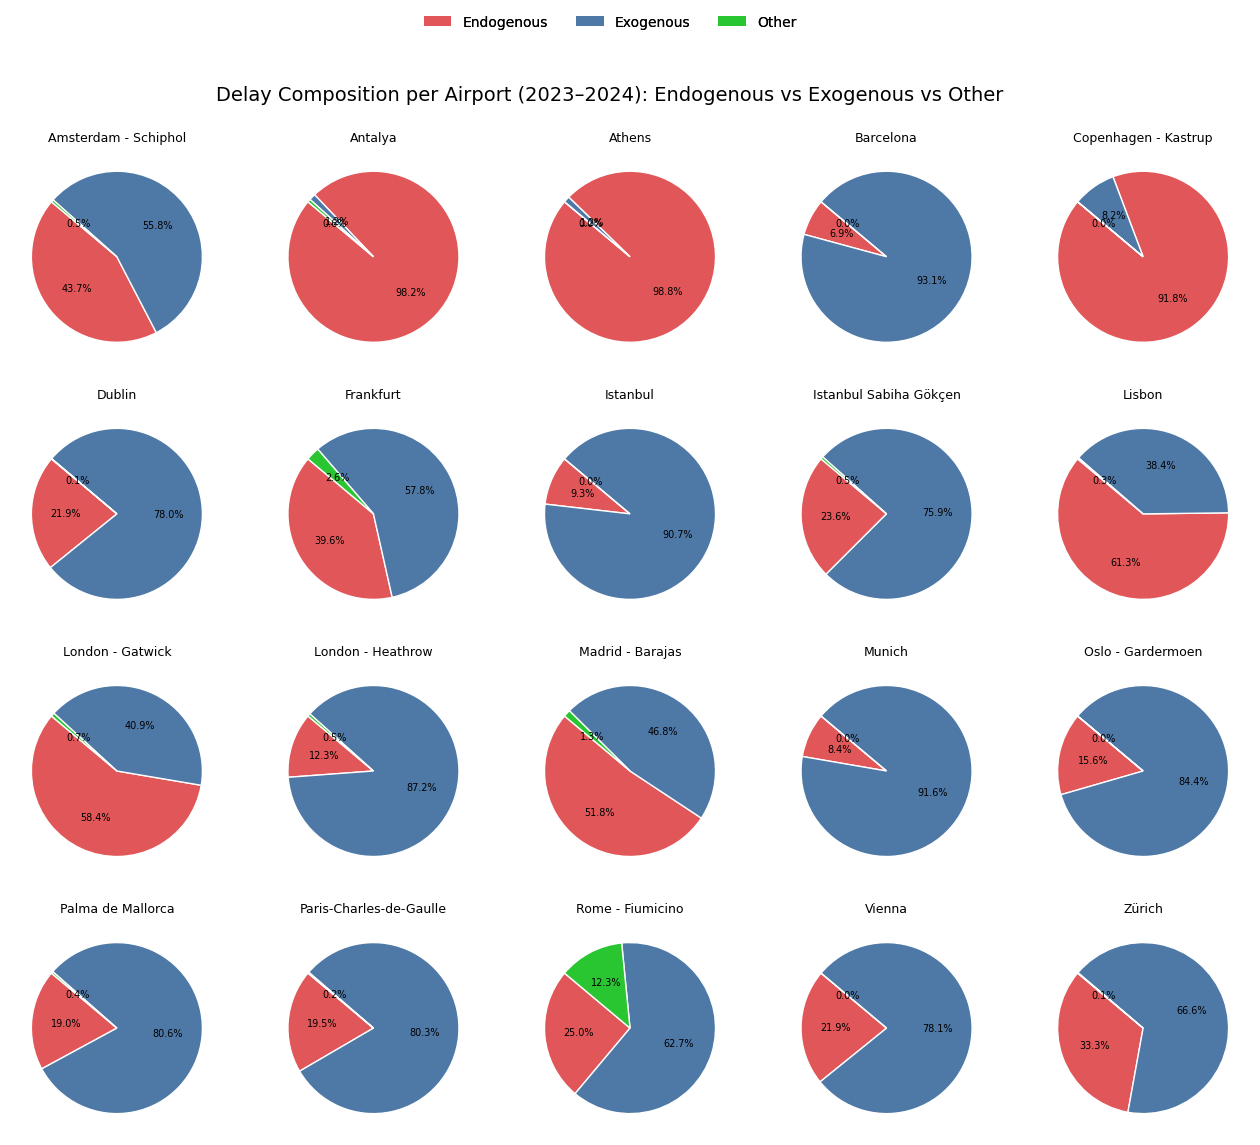

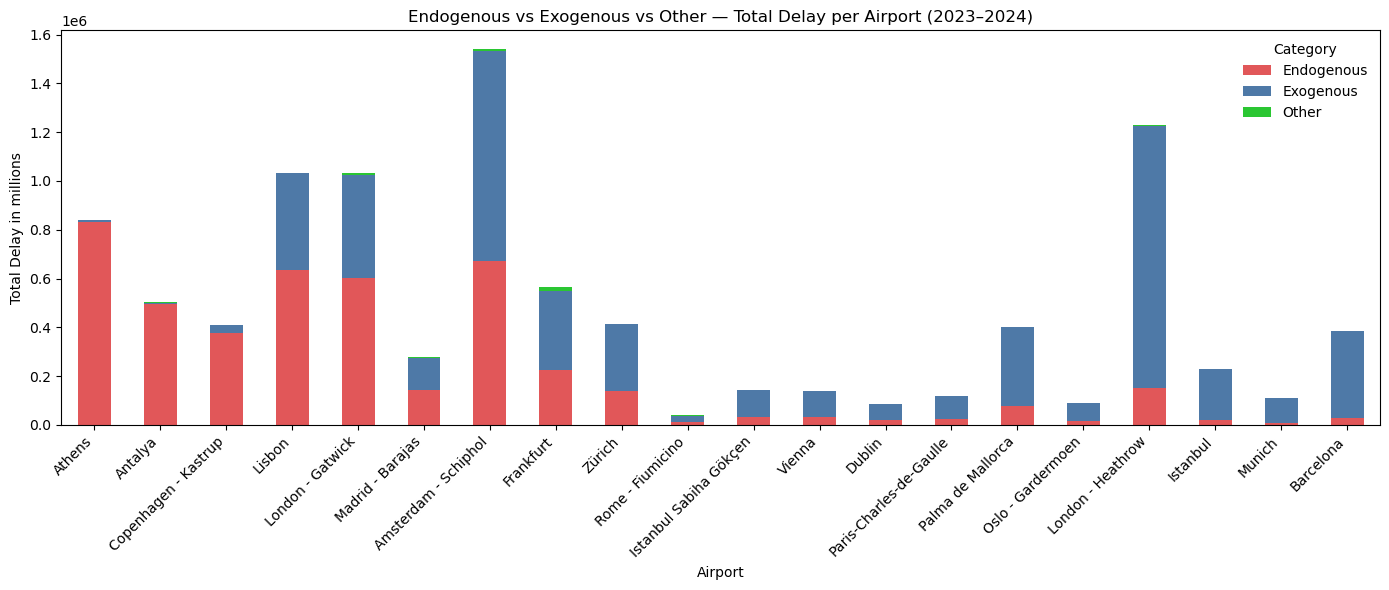

In [12]:
agg_airport["Exogenous"]  = agg_airport[EXOGENOUS_CAUSES].sum(axis=1)
agg_airport["Endogenous"] = agg_airport[ENDOGENOUS_CAUSES].sum(axis=1)
agg_airport["Other"]      = agg_airport[OTHER_CAUSES].sum(axis=1)

split3 = agg_airport[["APT_ICAO", "APT_NAME", "Exogenous", "Endogenous", "Other"]].copy()


fig, axes = plt.subplots(
    (len(split3) + 4) // 5, 5, figsize=(16, 3.2 * ((len(split3) + 4) // 5))
)
axes = axes.flatten()

labels = ["Endogenous", "Exogenous", "Other"]
color_map = {"Endogenous": "#E15759", "Exogenous": "#4E79A7", "Other": "#2AC632"}
color_list = [color_map[k] for k in labels]

#draw pies
for i, (_, r) in enumerate(split3.sort_values("APT_NAME").iterrows()):
    vals = [r["Endogenous"], r["Exogenous"], r["Other"]]
    axes[i].pie(
        vals,
        labels=None,
        colors=color_list,
        autopct="%1.1f%%",
        startangle=140,
        textprops={"fontsize": 7},
        wedgeprops={"linewidth": 1, "edgecolor": "white"}
    )
    axes[i].set_title(r["APT_NAME"], fontsize=9)

#shared legend
handles = [mpatches.Patch(facecolor=color_map[k], label=k) for k in labels]
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.995)
)

handles = [mpatches.Patch(facecolor=color_map[k], label=k) for k in labels]
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.995)
)

plt.suptitle("Delay Composition per Airport (2023–2024): Endogenous vs Exogenous vs Other",
             fontsize=14, y=0.93)
plt.show()

#bar chart
bars = split3.copy()
total = bars[["Exogenous", "Endogenous", "Other"]].sum(axis=1)
bars["Endogenous%"] = bars["Endogenous"] / total
bars = bars.sort_values("Endogenous%", ascending=False)

bars.set_index("APT_NAME")[["Endogenous", "Exogenous", "Other"]].plot(
    kind="bar", stacked=True, figsize=(14, 6),
    color=[color_map["Endogenous"], color_map["Exogenous"], color_map["Other"]]
)
plt.title("Endogenous vs Exogenous vs Other — Total Delay per Airport (2023–2024)")
plt.ylabel("Total Delay in millions")
plt.xlabel("Airport")
plt.xticks(rotation=45, ha="right")

plt.legend(handles=handles, title="Category", loc="upper right", frameon=False)
plt.tight_layout()
plt.show()





Endogenous delays originate from within the aviation system, such as air traffic control, staffing, or capacity constraints. While exogenous delays arise from external factors like weather or environmental conditions.

From the first set of pie charts, it is evident that airports such as Athens and Antalya are dominated by endogenous delays (over 90%), indicating that their delay issues are primarily driven by internal operational or airspace management constraints. In contrast, airports like London Heathrow, Paris Charles-de-Gaulle, Palma de Mallorca, and Dublin experience predominantly exogenous delays, with weather being the most significant contributing factor. Airports such as Amsterdam–Schiphol and Frankfurt show a more balanced composition, with both internal (endogenous) and external (exogenous) factors playing major roles.

The second figure reinforces these observations through a bar chart that compares total delay volumes by category and airport. It highlights that Amsterdam–Schiphol and London Heathrow have the highest overall delays, mostly driven by exogenous causes. And London Heathrow have as many endogenous delays as other smaller airports. Highlighting that London Heathrow is doing expetional well within it's limits and as a major hub. Even Schiphol are, relative to volume of flights and their endogenous delays, not doing as bad as previous charts and graphs suggest.

To give an final answer to the reserach question of chapter 1.1. What type of delays are occurring most at the airports related to air traffic? Across all visualizations, the dominant delay drivers across European airports are weather-related and capacity-linked. Both of which fall under Air Traffic Flow Management (ATFM) issues. Weather remains the most consistent exogenous factor, while aerodrome and ATC capacity constraints are the main endogenous causes. Airports with higher traffic volumes tend to experience a blend of both types, whereas others face more localized operational inefficiencies. Major airports seem like there doing bad but a better look into the data suggests otherwise.